# SIT225 6D - Activity Annotation Analysis

Loads accelerometer windows + annotation.csv and compares no-activity / waving / shaking.

In [39]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

%matplotlib inline
plt.rcParams["figure.dpi"] = 110


In [40]:
# ---- Configuration ----
DATA_DIR = "data_combined"                     # folder with <seq>_<timestamp>.csv / .jpg pairs
ANNOTATION_FILE = "annotation.csv"    # filename,label

LABEL_NAMES = {0: "no-activity", 1: "activity 1", 2: "activity 2"}


## 1. Load annotation file and accelerometer windows

In [42]:
annotations = pd.read_csv(ANNOTATION_FILE)
# normalise column names in case the file was created with different headers
annotations.columns = [c.strip().lower() for c in annotations.columns]
assert {"filename", "label"}.issubset(annotations.columns), (
    "annotation.csv must have 'filename' and 'label' columns"
)
annotations["filename"] = annotations["filename"].astype(str).str.replace(r"\.(csv|jpg)$", "", regex=True)
annotations["label"] = annotations["label"].astype(int)
annotations["activity"] = annotations["label"].map(LABEL_NAMES)

print(f"{len(annotations)} annotated windows")
annotations["activity"].value_counts()


123 annotated windows


activity
no-activity    56
activity 1     53
activity 2     14
Name: count, dtype: int64

In [43]:
def load_window(stem: str) -> pd.DataFrame | None:
    # Loads one window's accelerometer CSV given its filename stem.
    path = os.path.join(DATA_DIR, f"{stem}.csv")
    if not os.path.exists(path):
        print(f"[WARN] missing csv for {stem}")
        return None
    df = pd.read_csv(path)
    df.columns = [c.strip().lower() for c in df.columns]
    return df


def image_path(stem: str) -> str | None:
    path = os.path.join(DATA_DIR, f"{stem}.jpg")
    return path if os.path.exists(path) else None


## 2. Feature extraction per window

In [45]:
def extract_features(df: pd.DataFrame) -> dict:
    feats = {}
    for axis in ("x", "y", "z"):
        v = df[axis].to_numpy(dtype=float)
        feats[f"{axis}_mean"] = np.mean(v)
        feats[f"{axis}_std"] = np.std(v)
        feats[f"{axis}_range"] = np.ptp(v)
        feats[f"{axis}_rms"] = np.sqrt(np.mean(v ** 2))

    # Signal Magnitude Area — a common activity-recognition feature that
    # summarises overall movement intensity across all three axes
    mag = np.sqrt(df["x"] ** 2 + df["y"] ** 2 + df["z"] ** 2)
    feats["sma"] = float(np.mean(np.abs(df["x"])) + np.mean(np.abs(df["y"])) + np.mean(np.abs(df["z"])))
    feats["magnitude_mean"] = float(mag.mean())
    feats["magnitude_std"] = float(mag.std())

    # crude dominant-frequency estimate on the magnitude signal (assumes
    # roughly evenly spaced samples within the window)
    n = len(mag)
    if n >= 4:
        fft_vals = np.abs(np.fft.rfft(mag - mag.mean()))
        freqs = np.fft.rfftfreq(n)
        dominant_freq = freqs[np.argmax(fft_vals[1:]) + 1] if len(fft_vals) > 1 else 0.0
    else:
        dominant_freq = 0.0
    feats["dominant_freq"] = float(dominant_freq)
    feats["n_samples"] = n
    return feats


In [46]:
records = []
for _, row in annotations.iterrows():
    df = load_window(row["filename"])
    if df is None or df.empty:
        continue
    feats = extract_features(df)
    feats["filename"] = row["filename"]
    feats["label"] = row["label"]
    feats["activity"] = row["activity"]
    records.append(feats)

features_df = pd.DataFrame.from_records(records)
print(f"Loaded features for {len(features_df)} / {len(annotations)} annotated windows")
features_df.head()


Loaded features for 123 / 123 annotated windows


,x_mean,x_std,x_range,x_rms,y_mean,y_std,y_range,y_rms,z_mean,z_std,z_range,z_rms,sma,magnitude_mean,magnitude_std,dominant_freq,n_samples,filename,label,activity
0,-0.429100,0.383827,0.767654,0.575717,-0.746193,0.303581,0.607162,0.805584,0.060562,0.239670,0.479340,0.247203,1.414963,0.938252,0.567818,0.0,2,1_20260921223231,1,activity 1
1,0.312021,0.767596,2.159119,0.828589,-0.530130,0.360592,0.899551,0.641143,-0.019620,0.209898,0.625473,0.210813,1.436215,1.021505,0.351061,0.4,5,2_20260921223247,1,activity 1
2,0.395935,0.750971,1.834610,0.848953,-0.577413,0.437416,1.062881,0.724388,0.306381,0.070130,0.167145,0.314305,1.601527,1.137176,0.276796,0.0,3,3_20260921223258,1,activity 1
3,1.502686,1.198462,2.759323,1.922076,-0.724838,0.192326,0.470383,0.749920,-0.024343,0.074822,0.182602,0.078683,2.293482,1.811808,1.212620,0.0,3,4_20260921223310,2,activity 2
4,-1.696465,0.040657,0.081314,1.696952,0.005943,0.223305,0.446609,0.223384,-0.041138,0.046768,0.093536,0.062286,1.966537,1.712259,0.056474,0.0,2,5_20260921225416,0,no-activity


## 3. Class balance

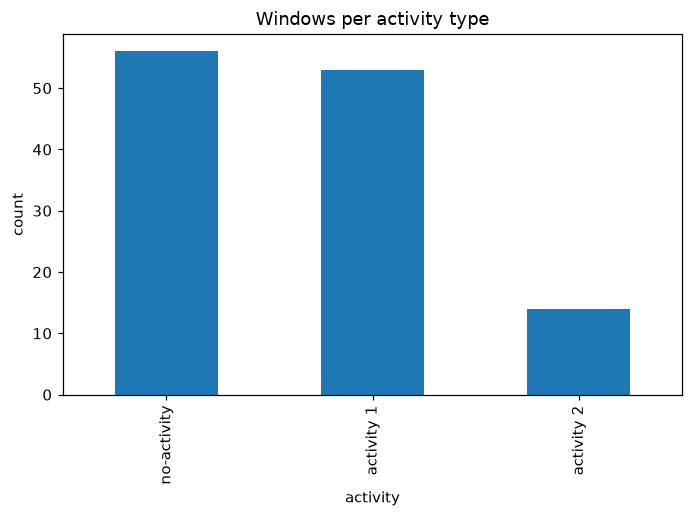

activity
no-activity    56
activity 1     53
activity 2     14
Name: count, dtype: int64

In [48]:
counts = features_df["activity"].value_counts()
ax = counts.plot(kind="bar", title="Windows per activity type")
ax.set_ylabel("count")
plt.tight_layout()
plt.show()
counts


## 4. Signal overlays per activity

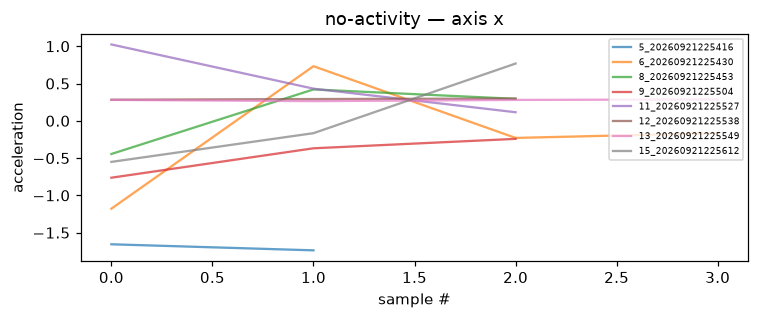

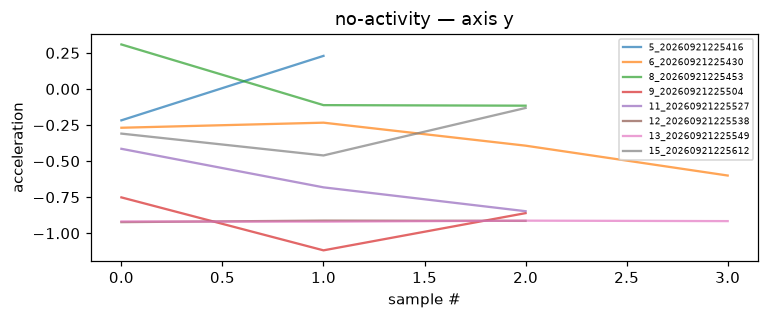

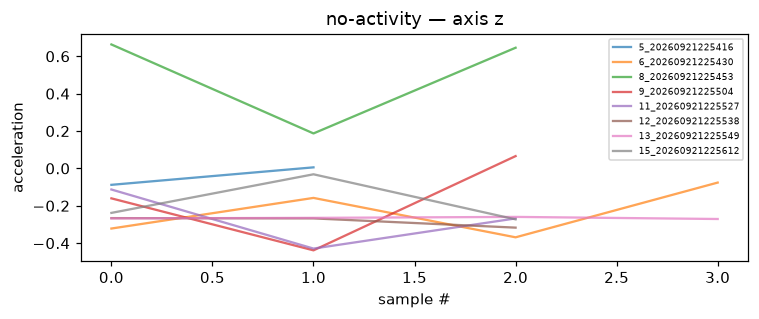

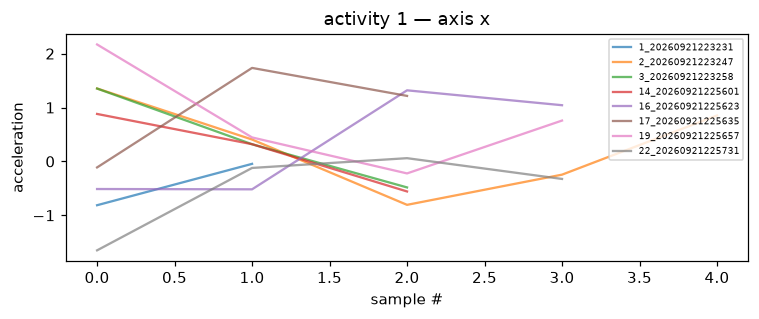

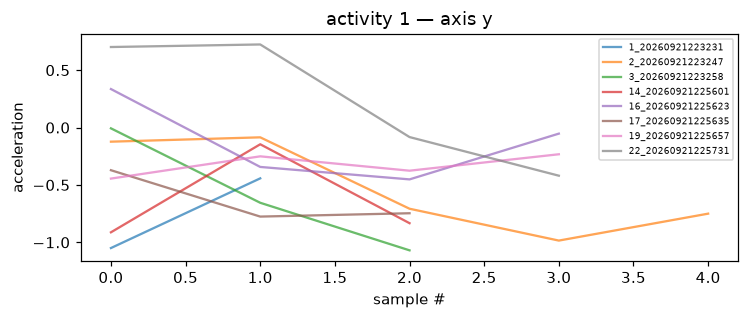

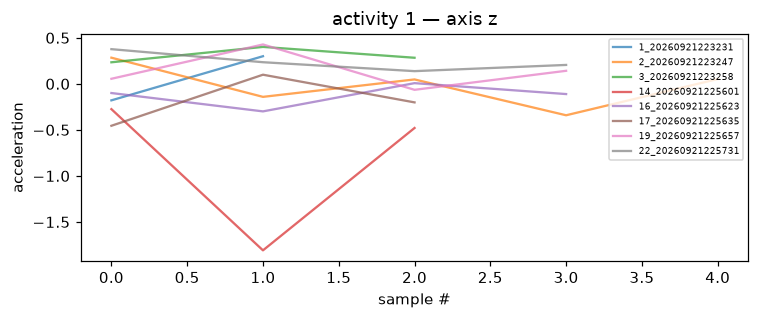

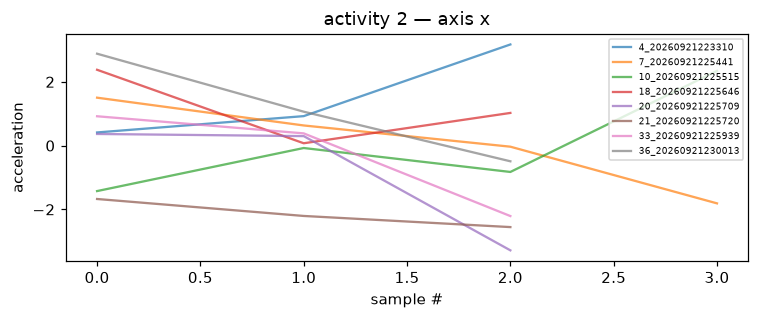

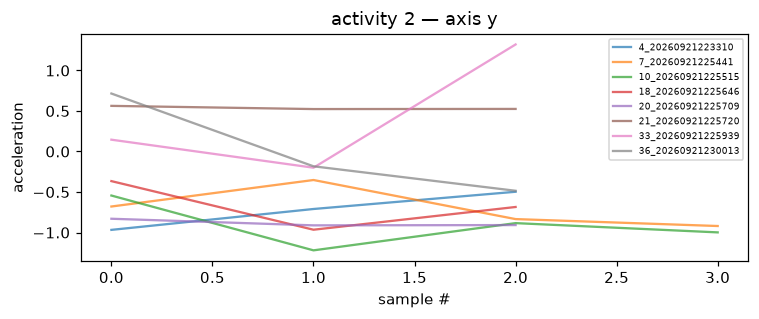

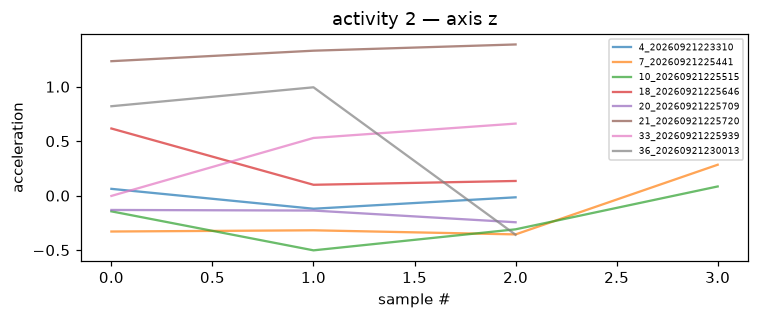

In [50]:
def plot_overlay_for_activity(label: int, axis: str, max_windows: int = 8):
    subset = features_df[features_df["label"] == label]["filename"].tolist()[:max_windows]
    plt.figure(figsize=(7, 3))
    for stem in subset:
        df = load_window(stem)
        if df is not None:
            plt.plot(df[axis].to_numpy(), alpha=0.7, label=stem)
    plt.title(f"{LABEL_NAMES[label]} — axis {axis}")
    plt.xlabel("sample #")
    plt.ylabel("acceleration")
    if len(subset) <= 8:
        plt.legend(fontsize=6, loc="upper right")
    plt.tight_layout()
    plt.show()

for label in sorted(LABEL_NAMES):
    for axis in ("x", "y", "z"):
        plot_overlay_for_activity(label, axis)


## 5. Activity images alongside signal

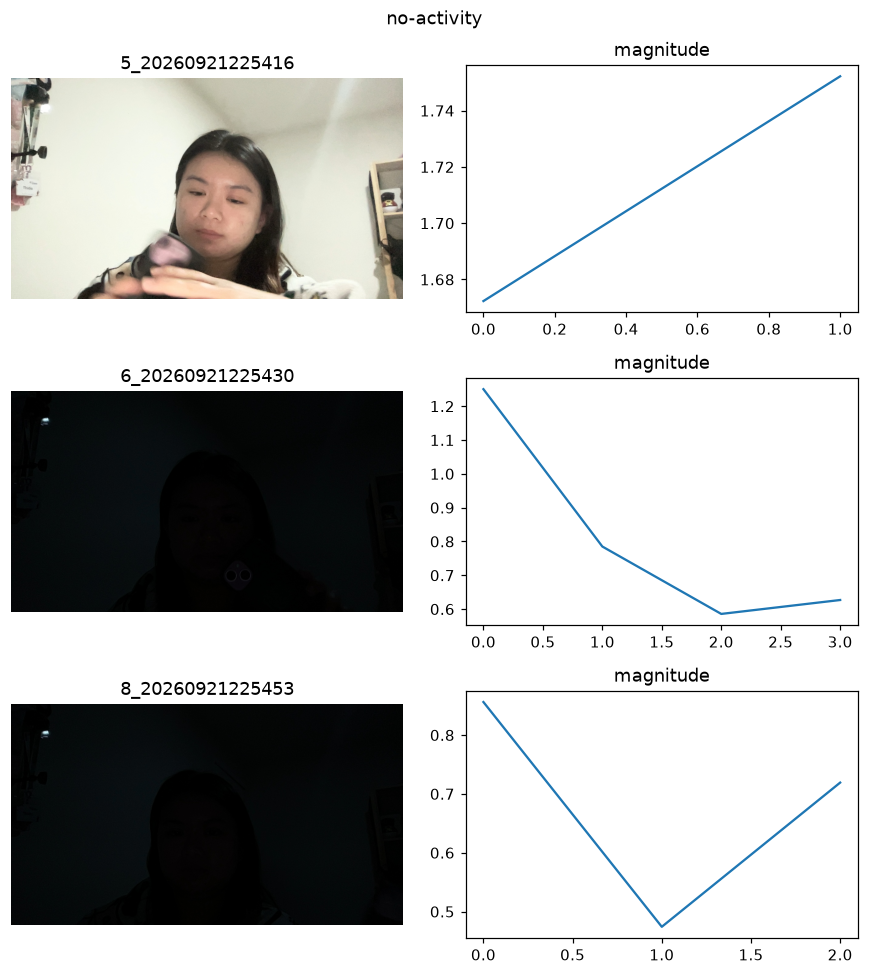

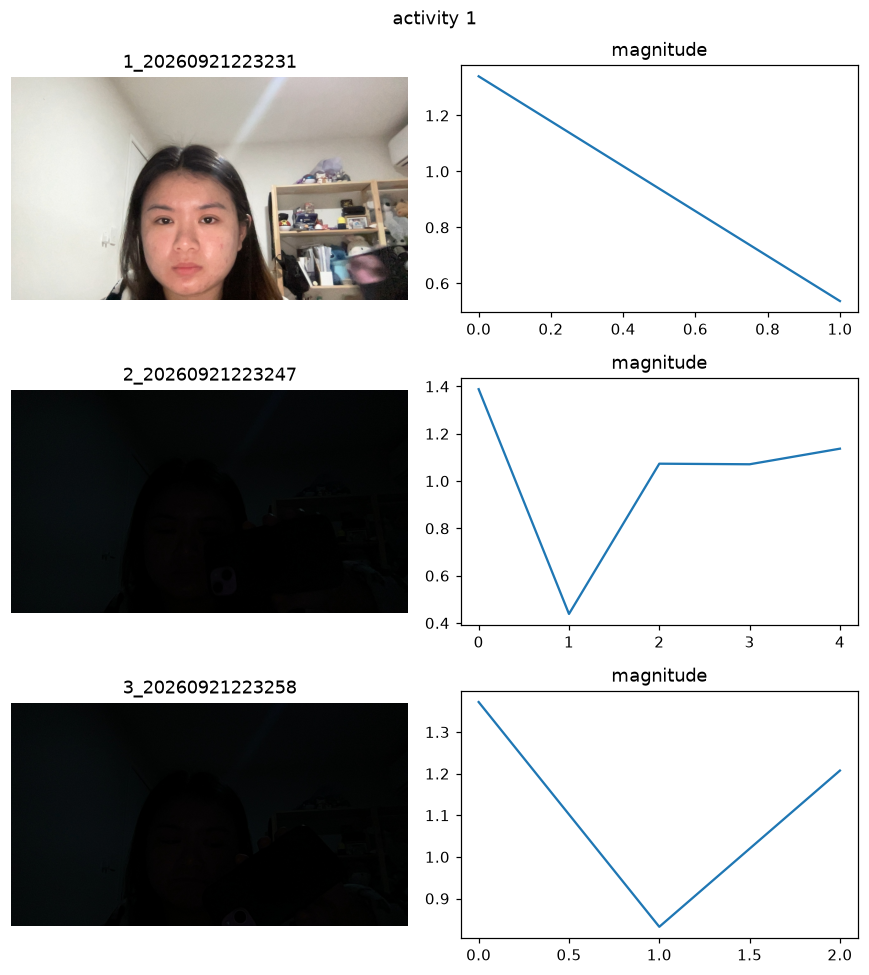

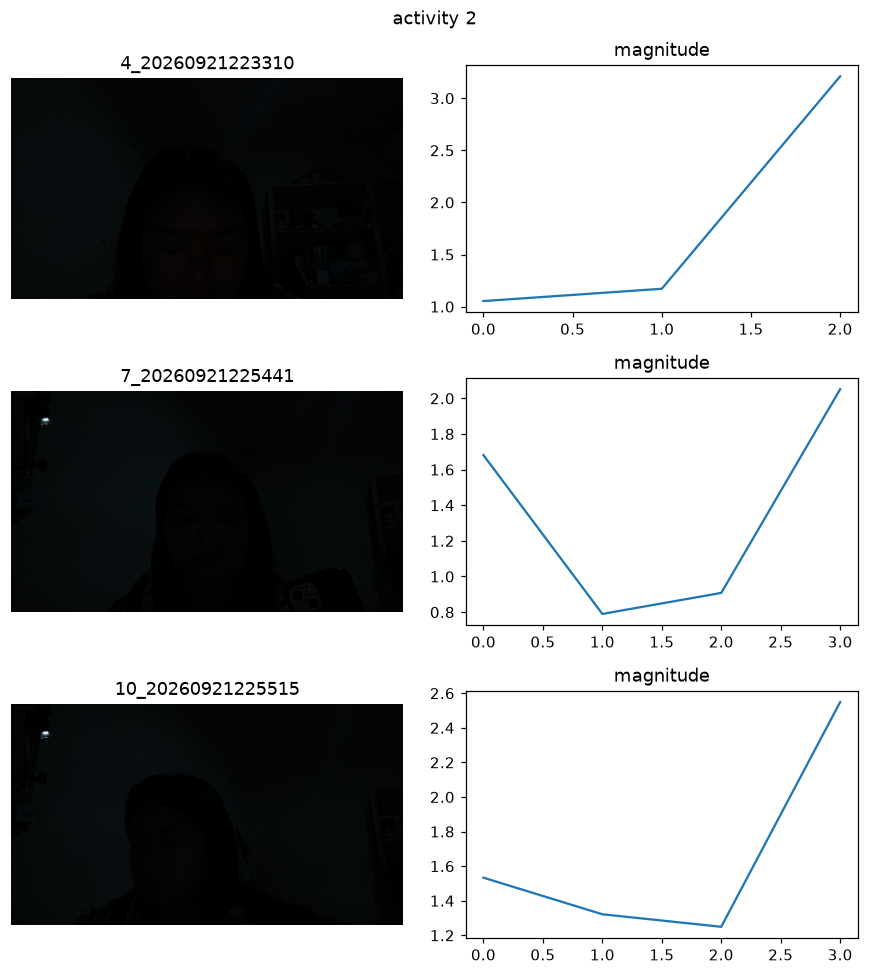

In [52]:
import matplotlib.image as mpimg

def show_examples(label: int, n: int = 3):
    subset = features_df[features_df["label"] == label]["filename"].tolist()[:n]
    fig, axes = plt.subplots(len(subset), 2, figsize=(8, 3 * len(subset)))
    if len(subset) == 1:
        axes = [axes]
    for row_ax, stem in zip(axes, subset):
        img_path = image_path(stem)
        df = load_window(stem)
        if img_path:
            row_ax[0].imshow(mpimg.imread(img_path))
        row_ax[0].set_title(stem)
        row_ax[0].axis("off")
        if df is not None:
            mag = np.sqrt(df["x"] ** 2 + df["y"] ** 2 + df["z"] ** 2)
            row_ax[1].plot(mag.to_numpy())
            row_ax[1].set_title("magnitude")
    plt.suptitle(LABEL_NAMES[label])
    plt.tight_layout()
    plt.show()

for label in sorted(LABEL_NAMES):
    show_examples(label)


## 6. Feature comparison across activities

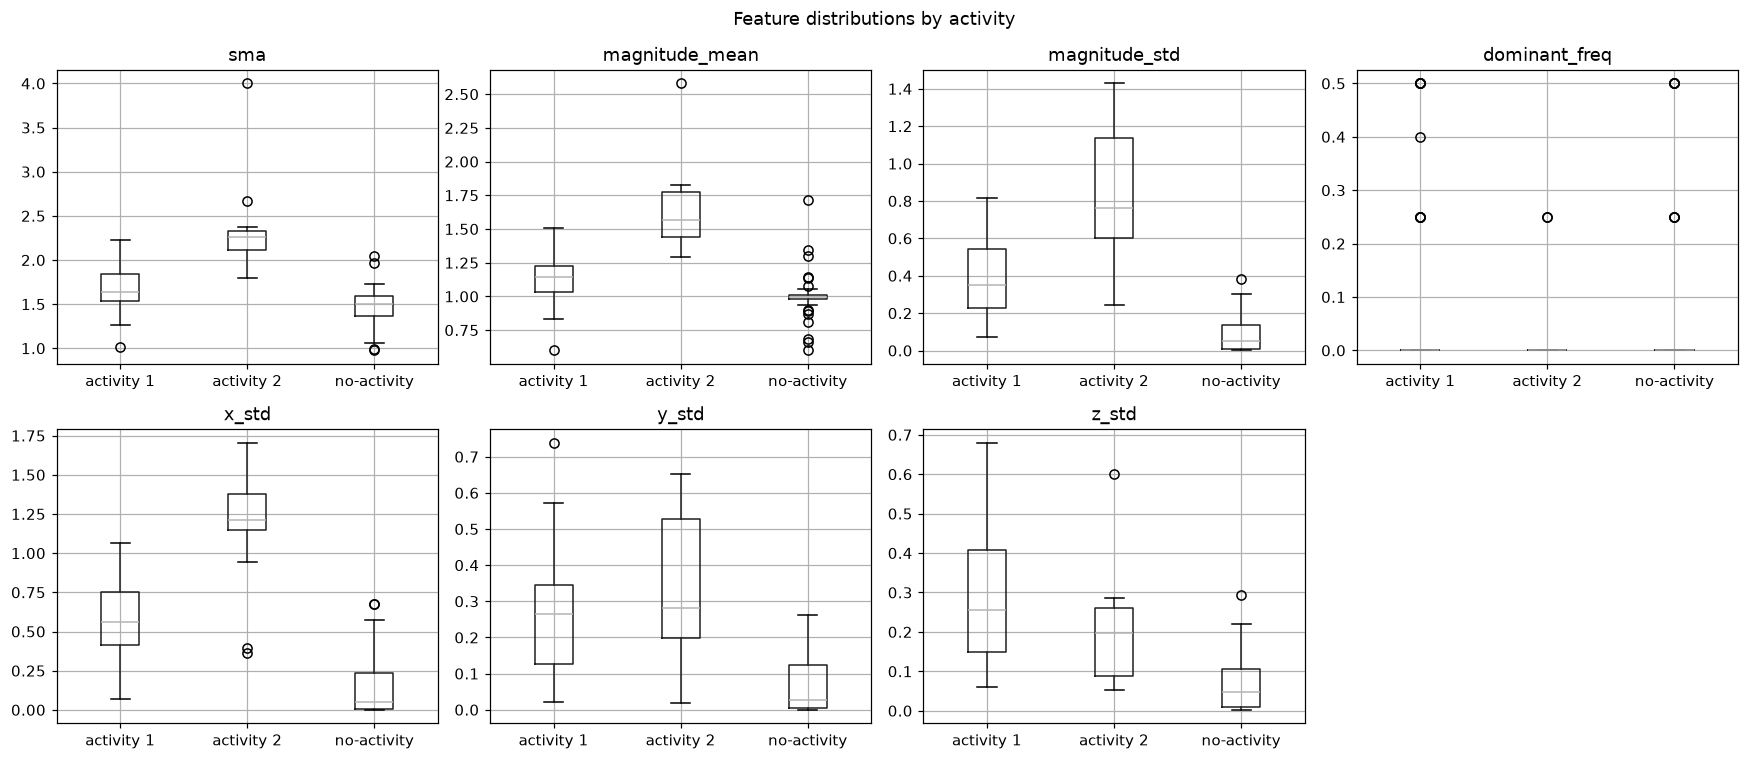

In [54]:
feature_cols = ["sma", "magnitude_mean", "magnitude_std", "dominant_freq",
                "x_std", "y_std", "z_std"]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
for ax, col in zip(axes, feature_cols):
    features_df.boxplot(column=col, by="activity", ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
for ax in axes[len(feature_cols):]:
    ax.axis("off")
plt.suptitle("Feature distributions by activity")
plt.tight_layout()
plt.show()


## 7. Pairwise statistical contrasts

In [56]:
def compare_pair(label_a: int, label_b: int) -> pd.DataFrame:
    a = features_df[features_df["label"] == label_a]
    b = features_df[features_df["label"] == label_b]
    rows = []
    for col in feature_cols:
        if len(a[col].dropna()) < 2 or len(b[col].dropna()) < 2:
            continue
        t_stat, p_val = stats.ttest_ind(a[col], b[col], equal_var=False)
        rows.append({
            "feature": col,
            f"mean_{LABEL_NAMES[label_a]}": a[col].mean(),
            f"mean_{LABEL_NAMES[label_b]}": b[col].mean(),
            "t_stat": t_stat,
            "p_value": p_val,
            "significant (p<0.05)": p_val < 0.05,
        })
    return pd.DataFrame(rows)

pairs = [(0, 1), (0, 2), (1, 2)]
comparison_tables = {}
for a, b in pairs:
    print(f"\n=== {LABEL_NAMES[a]} vs {LABEL_NAMES[b]} ===")
    table = compare_pair(a, b)
    comparison_tables[(a, b)] = table
    display(table)



=== no-activity vs activity 1 ===


,feature,mean_no-activity,mean_activity 1,t_stat,p_value,significant (p<0.05)
0,sma,1.469763,1.673847,-4.561773,1.447196e-05,True
1,magnitude_mean,1.001203,1.133075,-4.276766,4.239207e-05,True
2,magnitude_std,0.081012,0.381523,-10.126554,1.925930e-15,True
3,dominant_freq,0.049107,0.073585,-0.844614,4.002975e-01,False
4,x_std,0.150594,0.572070,-10.220221,3.381595e-17,True
5,y_std,0.065341,0.262484,-8.452676,2.007359e-12,True
6,z_std,0.064877,0.277196,-9.134651,1.447480e-13,True



=== no-activity vs activity 2 ===


,feature,mean_no-activity,mean_activity 2,t_stat,p_value,significant (p<0.05)
0,sma,1.469763,2.333117,-6.057579,2.929451e-05,True
1,magnitude_mean,1.001203,1.647956,-7.353218,2.993758e-06,True
2,magnitude_std,0.081012,0.810228,-7.724668,2.681186e-06,True
3,dominant_freq,0.049107,0.035714,0.439074,6.637464e-01,False
4,x_std,0.150594,1.169989,-9.728817,8.799083e-08,True
5,y_std,0.065341,0.334695,-4.511359,5.140365e-04,True
6,z_std,0.064877,0.200639,-3.464028,3.624050e-03,True



=== activity 1 vs activity 2 ===


,feature,mean_activity 1,mean_activity 2,t_stat,p_value,significant (p<0.05)
0,sma,1.673847,2.333117,-4.571202,0.000387,True
1,magnitude_mean,1.133075,1.647956,-5.797532,0.000035,True
2,magnitude_std,0.381523,0.810228,-4.396187,0.000501,True
3,dominant_freq,0.073585,0.035714,1.148708,0.257935,False
4,x_std,0.572070,1.169989,-5.601707,0.000042,True
5,y_std,0.262484,0.334695,-1.153121,0.265271,False
6,z_std,0.277196,0.200639,1.751162,0.093893,False


## 8. Feature separability

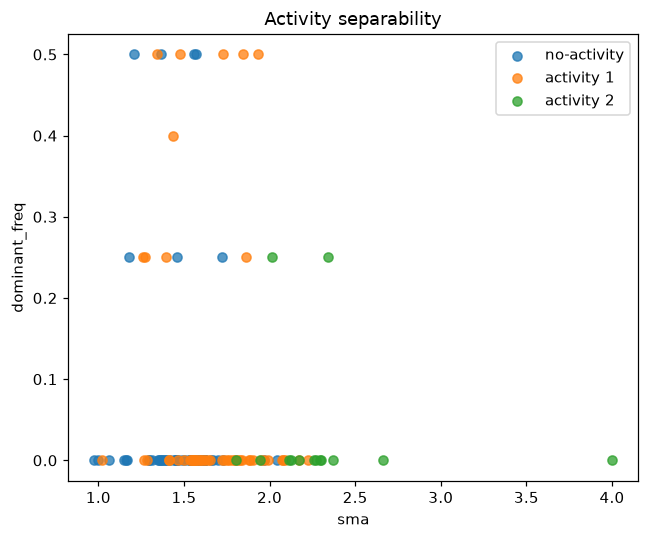

In [58]:
x_feat, y_feat = "sma", "dominant_freq"   # swap for whichever pair looks most discriminating above

plt.figure(figsize=(6, 5))
for label, name in LABEL_NAMES.items():
    subset = features_df[features_df["label"] == label]
    plt.scatter(subset[x_feat], subset[y_feat], label=name, alpha=0.75)
plt.xlabel(x_feat)
plt.ylabel(y_feat)
plt.legend()
plt.title("Activity separability")
plt.tight_layout()
plt.show()


## 9. Windows that don't match their assigned label

In [60]:
centroids = features_df.groupby("label")[feature_cols].mean()

def nearest_label(row):
    dists = {lbl: np.linalg.norm(row[feature_cols].values - centroids.loc[lbl].values) for lbl in centroids.index}
    return min(dists, key=dists.get)

features_df["nearest_centroid_label"] = features_df.apply(nearest_label, axis=1)
mismatches = features_df[features_df["label"] != features_df["nearest_centroid_label"]]
mismatches[["filename", "label", "activity", "nearest_centroid_label"]].assign(
    nearest_centroid_activity=lambda d: d["nearest_centroid_label"].map(LABEL_NAMES)
)


,filename,label,activity,nearest_centroid_label,nearest_centroid_activity
5,6_20260921225430,0,no-activity,1,activity 1
31,32_20260921225927,1,activity 1,0,no-activity
43,44_20260921230143,1,activity 1,0,no-activity
44,45_20260921230155,2,activity 2,1,activity 1
54,55_20260921230419,0,no-activity,1,activity 1
58,59_20260921230504,1,activity 1,0,no-activity
63,65_20260921230613,0,no-activity,1,activity 1
71,73_20260921230743,0,no-activity,1,activity 1
94,96_20260921231204,1,activity 1,0,no-activity
96,98_20260921231227,1,activity 1,0,no-activity
